# oil

This example joins two datasets into one.
Each row is a date. Columns are:
- `brent` Brent Crude oil prices
- `texas` West Texas Intermediate oil prices

Project ideas:
- Plot the difference between these prices.
- Find the min, max, and mean difference for each year.


In [1]:
from pathlib import Path
import pandas as pd

In [2]:
# Where are the datasets on your computer?
PRICES_DIR = Path.cwd().parent / "data" / "prices"
DATA_PATHS = {
    "brent": PRICES_DIR / "oil_brent.csv",
    "texas": PRICES_DIR / "oil_wti.csv",
}
for name, path in DATA_PATHS.items():
    print(f"{name} prices are here: {path}")

brent prices are here: /Users/void/code/chengdu/science/data/prices/oil_brent.csv
texas prices are here: /Users/void/code/chengdu/science/data/prices/oil_wti.csv


In [3]:
# Choose dates and create a DataFrame
dates = pd.date_range('2001-01-01', '2026-03-30')
prices = pd.DataFrame(index=dates)

# Load each column from a CSV file
for name, path in DATA_PATHS.items():
    prices[name] = pd.read_csv(
        path,
        parse_dates = True,
        index_col = 'Date',
)
    
prices

,brent,texas
2001-01-01,NaN,NaN
2001-01-02,23.43,27.29
2001-01-03,23.44,27.93
2001-01-04,24.57,27.95
2001-01-05,24.77,28.02
...,...,...
2026-03-26,113.39,96.18
2026-03-27,121.47,101.26
2026-03-28,NaN,NaN
2026-03-29,NaN,NaN


In [4]:
# Check data types
prices.dtypes

brent    float64
texas    float64
dtype: object

In [5]:
# Drop rows where all values are null
prices = prices.loc[prices.notnull().any(axis=1)]
print(f"{len(prices)} not-null rows remain")
prices.isnull().sum()

6459 not-null rows remain


brent     51
texas    130
dtype: int64

<Axes: title={'center': 'Crude oil prices'}, ylabel='USD'>

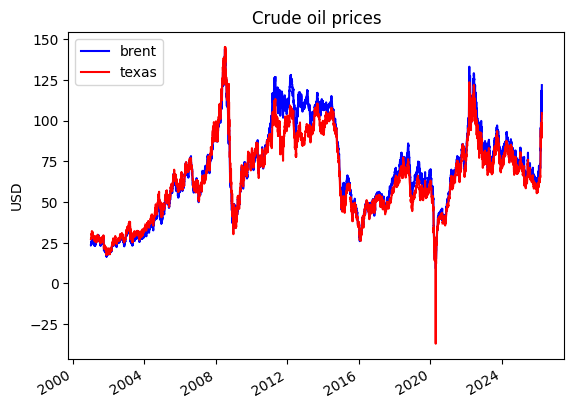

In [6]:
plotkw = {
    "title": "Crude oil prices",
    "ylabel": "USD",
    "color": 'br',
}
prices.plot(**plotkw)

Negative price dates:
[Timestamp('2020-04-20 00:00:00')]


<Axes: title={'center': 'Crude oil prices'}, ylabel='USD'>

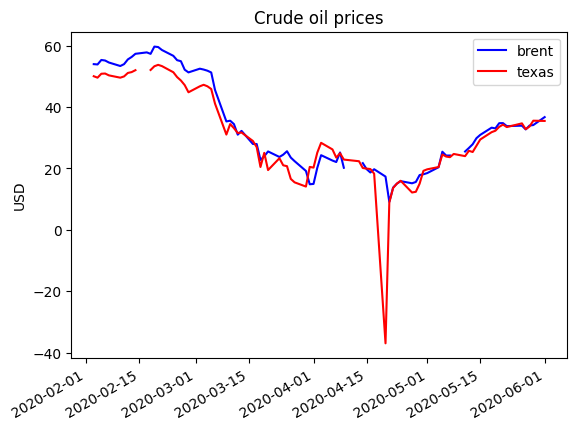

In [7]:
# Example project: Do I see negative prices?
# Zoom in on the plot around those dates.
from datetime import timedelta

print(f"Negative price dates:")
print(sorted(prices.loc[(prices < 0).any(axis=1)].index))
prices.loc['2020-02-01':'2020-06-01'].plot(**plotkw)